# Sigap.ai - Linear SVM Baseline for Sentiment Analysis

Notebook ini disusun untuk proyek capstone IBM SkillsBuild Sigap.ai sebagai baseline yang dapat langsung dijalankan di Google Colab.

Scope notebook ini dibatasi secara tegas pada data yang sudah final:
- proses data collection sudah selesai
- proses cleaning sudah selesai
- proses labeling sudah selesai
- proses balancing sudah selesai
- proses splitting sudah selesai
- proses preprocessing sudah selesai

Eksperimen ini hanya menggunakan:
- feature: `Review_Text_Processed`
- target: `Sentiment_Label`

Fokus utama notebook:
- membangun baseline Linear SVM yang kuat
- membandingkannya dengan Logistic Regression
- menyajikan evaluasi yang siap dipakai untuk laporan akademik dan advisor meeting

## SECTION 1 - Project Overview

### Tujuan eksperimen
Tujuan eksperimen ini adalah membangun baseline klasifikasi sentimen berbasis teks yang kuat, stabil, dan mudah diinterpretasikan untuk dataset review UMKM Indonesia pada proyek Sigap.ai. Hasil eksperimen akan dipakai sebagai benchmark untuk membandingkan model lanjutan berikutnya.

### Mengapa Linear SVM digunakan pada text classification
Linear SVM sangat sering menjadi baseline kuat untuk teks karena:
- efektif pada feature sparse berdimensi tinggi seperti TF-IDF
- memiliki margin maximization yang membantu generalisasi
- sering unggul pada problem klasifikasi teks dibanding model linear lain
- tetap relatif mudah dijelaskan melalui koefisien fitur pada kernel linear

### Perbedaan Logistic Regression dan SVM
Logistic Regression memodelkan probabilitas kelas secara langsung, sedangkan SVM berfokus pada pemisahan margin antar kelas.
Dalam praktik text classification:
- Logistic Regression sering lebih probabilistik dan lebih mudah diubah ke confidence score
- Linear SVM sering memberikan batas keputusan yang lebih tegas
- keduanya cocok sebagai baseline, tetapi SVM sering lebih kuat pada feature TF-IDF

## SECTION 2 - Import Library

Library yang digunakan dibatasi pada stack yang umum dipakai untuk eksperimen machine learning terstruktur:
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib

In [13]:
import os
from pathlib import Path
import re
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    MinMaxScaler
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    learning_curve,
    validation_curve
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from scipy.sparse import (
    hstack,
    csr_matrix
)

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

pd.set_option("display.max_colwidth", 250)
pd.set_option("display.max_columns", 100)

## SECTION 3 - Load Dataset

Notebook ini mencoba menemukan file dataset secara otomatis agar tetap fleksibel saat dijalankan di Google Colab maupun pada workspace lokal.

File yang didukung:
- `df_train_final.csv` atau `train_final.csv`
- `df_validation_final.csv` atau `validation_final.csv`
- `df_test_final.csv` atau `test_final.csv`

In [14]:
PROJECT_ROOT = Path.cwd()

TRAIN_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "train.csv"
VAL_PATH   = PROJECT_ROOT / "dataset" / "processed-dataset" / "validation.csv"
TEST_PATH  = PROJECT_ROOT / "dataset" / "processed-dataset" / "test.csv"

for path in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {path}")

train_df = pd.read_csv(TRAIN_PATH, encoding="utf-8-sig")
val_df   = pd.read_csv(VAL_PATH, encoding="utf-8-sig")
test_df  = pd.read_csv(TEST_PATH, encoding="utf-8-sig")

print("\nDataset Loaded Successfully")
print(f"Train      : {train_df.shape}")
print(f"Validation : {val_df.shape}")
print(f"Test       : {test_df.shape}")

print("\nColumns:")
print(train_df.columns.tolist())


Dataset Loaded Successfully
Train      : (37391, 9)
Validation : (8025, 9)
Test       : (8024, 9)

Columns:
['Review_Text', 'Review_Text_Processed', 'Review_Date', 'Rating_Score', 'Business_Category', 'Sentiment_Label', 'Review_Aspect', 'Crisis_Flag', 'Is_Sarcasm']


In [15]:
def load_split(path):

    if not path.exists():
        raise FileNotFoundError(
            f"Dataset tidak ditemukan: {path}"
        )

    df = pd.read_csv(
        path,
        encoding="utf-8-sig"
    )

    expected_columns = [
        "Review_Text",
        "Review_Text_Processed",
        "Rating_Score",
        "Business_Category",
        "Sentiment_Label",
        "Review_Aspect",
        "Crisis_Flag",
        "Is_Sarcasm",
    ]

    missing = [
        c for c in expected_columns
        if c not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{path.name} missing columns: {missing}"
        )

    return df


train_df = load_split(TRAIN_PATH)
val_df = load_split(VAL_PATH)
test_df = load_split(TEST_PATH)

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{split_name} shape: {df.shape}")

    print("\nLabel distribution:")
    display(
        df["Sentiment_Label"]
        .value_counts()
        .to_frame("count")
    )

    print("\nSample data:")
    display(
        df[
            [
                "Review_Text_Processed",
                "Sentiment_Label"
            ]
        ].head(5)
    )


Train shape: (37391, 9)

Label distribution:


,count
Sentiment_Label,
Negative,12499
Netral,12493
Positive,12399



Sample data:


,Review_Text_Processed,Sentiment_Label
0,terimakasih packing aman bagus,Positive
1,aplikasi bikin ribet pesan skor performa aneh apliksi,Netral
2,draftanakunpad3 cobain fore matchanya asa sen less sugar wktu pas tidak banyak susu cream,Netral
3,yummyyy cocok ngemil abis tarawih alhamdulillah harga lumayan obat kangen,Netral
4,with nice ambiance and sushi it may be called mahal but unfortunately the is not jangkau,Positive



Validation shape: (8025, 9)

Label distribution:


...

,Review_Text_Processed,Sentiment_Label
0,gojeg susah driver gocar gofood nunggu sampe jam,Negative
1,gila versi ter aneh banget fiturnya aneh cair dana ribet tolong baik,Negative
2,tagih tanggung rejeki wkwkwk beli,Positive
3,nothing much to say but got authentic north indian food in south india chole bhature were mouth watering lassi was thick fresh the suasana gives glimpse of an north indian roadside dhaba,Positive
4,belum coba moga fungsi bagus,Positive



Test shape: (8024, 9)

Label distribution:


,count
Sentiment_Label,
Negative,2680
Netral,2674
Positive,2670



Sample data:


,Review_Text_Processed,Sentiment_Label
0,this store maintains the kualitas brand name of domino their burger pizza is great in its perfect balance of spices the bland bread our was delivered on time and in good condition overall its alam,Positive
1,order gacor sengdangkan kouta ttp,Netral
2,giving coz had to take different cake not the one which chose,Positive
3,parah go gek masak order go food diemin hari saldo blum rekening ulang komplain admin msih lambat masuk saldo rekening uang hasil jual pakai modal bahan baku masakan resto evaluasi kerja sistem kerja adminya go food terima kasih,Negative
4,hi got cake from here which called some joy cake chocolate very good and delicioasa superb would recommend to anyone will try it again and again,Positive


Feature Engineering

## SECTION 4 - Label Encoding

Pada tahap ini label distandarkan menjadi `Positive`, `Neutral`, `Negative`, kemudian diencode agar kompatibel dengan model klasifikasi.
Mapping label disimpan agar interpretasi hasil tetap transparan.

In [16]:
def standardize_label(label):

    label = str(label).strip()

    mapping = {
        "netral": "Neutral",
        "neutral": "Neutral",
        "negative": "Negative",
        "positive": "Positive",
        "negatif": "Negative",
        "positif": "Positive"
    }

    return mapping.get(
        label.lower(),
        label
    )


for df in [train_df, val_df, test_df]:
    df["Sentiment_Label"] = (
        df["Sentiment_Label"]
        .apply(standardize_label)
    )


label_order = [
    "Negative",
    "Neutral",
    "Positive"
]

label_encoder = LabelEncoder()
label_encoder.fit(label_order)

label_mapping = {
    label: int(
        label_encoder.transform([label])[0]
    )
    for label in label_encoder.classes_
}

inverse_label_mapping = {
    v: k
    for k, v in label_mapping.items()
}

display(
    pd.DataFrame({
        "label": list(label_mapping.keys()),
        "encoded_value": list(label_mapping.values())
    })
)

train_y = label_encoder.transform(
    train_df["Sentiment_Label"]
)

val_y = label_encoder.transform(
    val_df["Sentiment_Label"]
)

test_y = label_encoder.transform(
    test_df["Sentiment_Label"]
)

print("Label mapping:", label_mapping)

,label,encoded_value
0,Negative,0
1,Neutral,1
2,Positive,2


Label mapping: {np.str_('Negative'): 0, np.str_('Neutral'): 1, np.str_('Positive'): 2}


In [17]:
assert set(train_df["Sentiment_Label"].unique()) == {
    "Negative",
    "Neutral",
    "Positive"
}

assert set(val_df["Sentiment_Label"].unique()) == {
    "Negative",
    "Neutral",
    "Positive"
}

assert set(test_df["Sentiment_Label"].unique()) == {
    "Negative",
    "Neutral",
    "Positive"
}

print("✓ Label validation passed")

✓ Label validation passed


In [18]:
def negation(text):

    text = str(text).lower()

    patterns = [
        (r"tidak\s+(\w+)", r"tidak_\1"),
        (r"tak\s+(\w+)", r"tak_\1"),
        (r"bukan\s+(\w+)", r"bukan_\1"),
        (r"belum\s+(\w+)", r"belum_\1"),
        (r"ga\s+(\w+)", r"ga_\1"),
        (r"gak\s+(\w+)", r"gak_\1"),
        (r"ngga\s+(\w+)", r"ngga_\1"),
        (r"nggak\s+(\w+)", r"nggak_\1"),
        (r"not\s+(\w+)", r"not_\1"),
    ]

    for pattern, replacement in patterns:
        text = re.sub(
            pattern,
            replacement,
            text
        )

    return text

In [19]:
for df in [train_df, val_df, test_df]:

    df["Review_Text_Processed"] = (
        df["Review_Text_Processed"]
        .fillna("")
        .astype(str)
        .apply(negation)
    )

## SECTION 5 - TF-IDF Feature Engineering

Eksperimen TF-IDF dilakukan untuk membandingkan representasi teks yang berbeda sebelum model final dibangun.

Konfigurasi yang diuji:
- Unigram
- Bigram
- `max_features = 5000`
- `max_features = 10000`
- `max_features = 20000`

In [20]:
for df in [train_df, val_df, test_df]:

    df["review_len"] = (
        df["Review_Text_Processed"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

scaler = MinMaxScaler()

train_df["review_len"] = scaler.fit_transform(
    train_df[["review_len"]]
)

val_df["review_len"] = scaler.transform(
    val_df[["review_len"]]
)

test_df["review_len"] = scaler.transform(
    test_df[["review_len"]]
)

In [21]:
binary_mapping = {
    "Yes": 1,
    "No": 0,
    "yes": 1,
    "no": 0,
    "TRUE": 1,
    "FALSE": 0,
    "True": 1,
    "False": 0,
    True: 1,
    False: 0
}

for df in [train_df, val_df, test_df]:

    df["Crisis_Flag"] = (
        df["Crisis_Flag"]
        .map(binary_mapping)
        .fillna(0)
        .astype("int8")
    )

    df["Is_Sarcasm"] = (
        df["Is_Sarcasm"]
        .map(binary_mapping)
        .fillna(0)
        .astype("int8")
    )

In [22]:
X_train = train_df["Review_Text_Processed"].fillna("").astype(str)
X_val = val_df["Review_Text_Processed"].fillna("").astype(str)
X_test = test_df["Review_Text_Processed"].fillna("").astype(str)

# =========================
# WORD TF-IDF
# =========================

word_tfidf = TfidfVectorizer(
    analyzer="word",
    lowercase=True,
    strip_accents="unicode",
    sublinear_tf=True,
    smooth_idf=True,
    norm="l2",
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

# =========================
# CHAR TF-IDF
# =========================

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    lowercase=True,
    sublinear_tf=True,
    smooth_idf=True,
    norm="l2",
    ngram_range=(3, 5),
    min_df=2,
    max_features=30000
)

X_train_word = word_tfidf.fit_transform(X_train)
X_val_word = word_tfidf.transform(X_val)
X_test_word = word_tfidf.transform(X_test)

X_train_char = char_tfidf.fit_transform(X_train)
X_val_char = char_tfidf.transform(X_val)
X_test_char = char_tfidf.transform(X_test)

# =========================
# CATEGORICAL FEATURES
# =========================

categorical_features = [
    "Business_Category",
    "Review_Aspect"
]

ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

train_cat = ohe.fit_transform(
    train_df[categorical_features]
)

val_cat = ohe.transform(
    val_df[categorical_features]
)

test_cat = ohe.transform(
    test_df[categorical_features]
)

# =========================
# NUMERIC FEATURES
# =========================

numeric_features = [
    "Crisis_Flag",
    "Is_Sarcasm",
    "review_len"
]

train_num = csr_matrix(
    train_df[numeric_features]
    .astype("float32")
    .values
)

val_num = csr_matrix(
    val_df[numeric_features]
    .astype("float32")
    .values
)

test_num = csr_matrix(
    test_df[numeric_features]
    .astype("float32")
    .values
)

# =========================
# FEATURE CONCATENATION
# =========================

X_train_final = hstack([
    X_train_word,
    X_train_char,
    train_cat,
    train_num
])

X_val_final = hstack([
    X_val_word,
    X_val_char,
    val_cat,
    val_num
])

X_test_final = hstack([
    X_test_word,
    X_test_char,
    test_cat,
    test_num
])

print("Train Shape :", X_train_final.shape)
print("Val Shape   :", X_val_final.shape)
print("Test Shape  :", X_test_final.shape)

print("Word Features :", len(word_tfidf.get_feature_names_out()))
print("Char Features :", len(char_tfidf.get_feature_names_out()))

Train Shape : (37391, 80019)
Val Shape   : (8025, 80019)
Test Shape  : (8024, 80019)
Word Features : 50000
Char Features : 30000


In [23]:
categorical_features = [
    "Business_Category",
    "Review_Aspect"
]

ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

train_cat = ohe.fit_transform(
    train_df[categorical_features]
)

val_cat = ohe.transform(
    val_df[categorical_features]
)

test_cat = ohe.transform(
    test_df[categorical_features]
)

In [24]:

for df in [train_df, val_df, test_df]:

    df["Crisis_Flag"] = (
        df["Crisis_Flag"]
        .map({
            "Yes": 1,
            "No": 0
        })
        .fillna(0)
        .astype("int32")
    )

    df["Is_Sarcasm"] = (
        df["Is_Sarcasm"]
        .map({
            "Yes": 1,
            "No": 0
        })
        .fillna(0)
        .astype("int32")
    )

numeric_features = [
    "Crisis_Flag",
    "Is_Sarcasm",
    "review_len"
]

train_num = csr_matrix(
    train_df[numeric_features]
    .astype("float32")
    .values
)

val_num = csr_matrix(
    val_df[numeric_features]
    .astype("float32")
    .values
)

test_num = csr_matrix(
    test_df[numeric_features]
    .astype("float32")
    .values
)

print("Numeric features ready")
print(train_num.shape)
print(val_num.shape)
print(test_num.shape)

Numeric features ready
(37391, 3)
(8025, 3)
(8024, 3)


In [25]:
X_train_final = hstack([
    X_train_word,
    X_train_char,
    train_cat,
    train_num
])

X_val_final = hstack([
    X_val_word,
    X_val_char,
    val_cat,
    val_num
])

X_test_final = hstack([
    X_test_word,
    X_test_char,
    test_cat,
    test_num
])

X_train_final = X_train_final.tocsr()
X_val_final = X_val_final.tocsr()
X_test_final = X_test_final.tocsr()

print("Train Shape :", X_train_final.shape)
print("Val Shape   :", X_val_final.shape)
print("Test Shape  :", X_test_final.shape)

Train Shape : (37391, 80019)
Val Shape   : (8025, 80019)
Test Shape  : (8024, 80019)


In [26]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(
    score_func=chi2,
    k=80000
)

X_train_selected = selector.fit_transform(
    X_train_final,
    train_y
)

X_val_selected = selector.transform(
    X_val_final
)

X_test_selected = selector.transform(
    X_test_final
)

print("Original Features :", X_train_final.shape[1])
print("Selected Features :", X_train_selected.shape[1])

Original Features : 80019
Selected Features : 80000


## SECTION 6 - Baseline Linear SVM

Baseline model dibangun menggunakan konfigurasi TF-IDF terbaik dari Section 5 dan `LinearSVC()` default.
Evaluasi dilakukan pada validation set untuk mendapatkan baseline yang kredibel sebelum tuning.

In [27]:
baseline_svm = LinearSVC(
    C=1.0,
    class_weight=None,
    loss="squared_hinge",
    max_iter=30000,
    random_state=42
)

baseline_svm.fit(
    X_train_selected,
    train_y
)

val_pred_baseline = baseline_svm.predict(
    X_val_selected
)

In [28]:
print("Baseline Accuracy :", accuracy_score(
    val_y,
    val_pred_baseline
))

print("Baseline F1 Macro :", f1_score(
    val_y,
    val_pred_baseline,
    average="macro"
))

Baseline Accuracy : 0.7517757009345795
Baseline F1 Macro : 0.7513648321097627


In [29]:
final_classifier = LinearSVC(
    C=5,
    class_weight=None,
    loss="squared_hinge",
    max_iter=30000,
    random_state=42
)

final_classifier.fit(
    X_train_selected,
    train_y
)

LinearSVC(C=5, max_iter=30000, random_state=42)

## SECTION 8 - Final Model Training

Final model dibangun menggunakan parameter terbaik dari GridSearchCV. Model kemudian dilatih ulang pada training set agar seluruh data latih berkontribusi pada parameter final.

In [30]:
param_grid = {
    "C": [0.5, 1, 2, 5, 10],
    "loss": ["squared_hinge"],
    "class_weight": [None]
}

grid_search = GridSearchCV(
    estimator=LinearSVC(
        max_iter=30000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    X_train_selected,
    train_y
)

print("=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)

print("Best Params :", grid_search.best_params_)
print("Best CV F1  :", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_

val_pred = best_model.predict(
    X_val_selected
)

test_pred = best_model.predict(
    X_test_selected
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
BEST HYPERPARAMETERS
Best Params : {'C': 0.5, 'class_weight': None, 'loss': 'squared_hinge'}
Best CV F1  : 0.7581


## SECTION 9 - Evaluation

Evaluasi dilakukan pada validation set dan test set dengan metrik berikut:
- Accuracy
- Precision
- Recall
- F1 Score

Selain metrik agregat, notebook juga menampilkan classification report lengkap untuk masing-masing split.

In [31]:
def evaluate_model(model, x, y, split_name):

    pred = model.predict(x)

    metrics = {
        "split": split_name,
        "accuracy": accuracy_score(y, pred),
        "precision_macro": precision_score(y, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y, pred, average="macro", zero_division=0),

        "precision_weighted": precision_score(y, pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y, pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y, pred, average="weighted", zero_division=0),
    }

    report_dict = classification_report(
        y,
        pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    report_df = (
        pd.DataFrame(report_dict)
        .T
        .reset_index()
        .rename(columns={"index": "label"})
    )

    return metrics, pred, report_df


val_metrics, val_pred, val_report_df = evaluate_model(
    best_model,
    X_val_selected,
    val_y,
    "validation"
)

test_metrics, test_pred, test_report_df = evaluate_model(
    best_model,
    X_test_selected,
    test_y,
    "test"
)

metrics_df = pd.DataFrame([val_metrics, test_metrics])
display(metrics_df)
display(val_report_df)
display(test_report_df)

print('Validation Classification Report')
print(classification_report(val_y, val_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

print('Test Classification Report')
print(classification_report(test_y, test_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

cm = confusion_matrix(
    test_y,
    test_pred
)

print("\nConfusion Matrix")
print(cm)

,split,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,validation,0.757882,0.756775,0.758048,0.757253,0.756654,0.757882,0.757110
1,test,0.764457,0.763047,0.764556,0.763557,0.762991,0.764457,0.763479


,label,precision,recall,f1-score,support
0,Negative,0.740927,0.716045,0.728273,2680.000000
1,Neutral,0.687617,0.686333,0.686974,2678.000000
2,Positive,0.841781,0.871766,0.856511,2667.000000
3,accuracy,0.757882,0.757882,0.757882,0.757882
4,macro avg,0.756775,0.758048,0.757253,8025.000000
5,weighted avg,0.756654,0.757882,0.757110,8025.000000


,label,precision,recall,f1-score,support
0,Negative,0.743370,0.711194,0.726926,2680.000000
1,Neutral,0.698430,0.698953,0.698692,2674.000000
2,Positive,0.847342,0.883521,0.865053,2670.000000
3,accuracy,0.764457,0.764457,0.764457,0.764457
4,macro avg,0.763047,0.764556,0.763557,8024.000000
5,weighted avg,0.762991,0.764457,0.763479,8024.000000


Validation Classification Report
              precision    recall  f1-score   support

    Negative     0.7409    0.7160    0.7283      2680
     Neutral     0.6876    0.6863    0.6870      2678
    Positive     0.8418    0.8718    0.8565      2667

    accuracy                         0.7579      8025
   macro avg     0.7568    0.7580    0.7573      8025
weighted avg     0.7567    0.7579    0.7571      8025

Test Classification Report
              precision    recall  f1-score   support

    Negative     0.7434    0.7112    0.7269      2680
     Neutral     0.6984    0.6990    0.6987      2674
    Positive     0.8473    0.8835    0.8651      2670

    accuracy                         0.7645      8024
   macro avg     0.7630    0.7646    0.7636      8024
weighted avg     0.7630    0.7645    0.7635      8024


Confusion Matrix
[[1906  620  154]
 [ 534 1869  271]
 [ 124  187 2359]]


## SECTION 10 - Visualization

Visualisasi dibuat untuk membantu interpretasi performa model secara akademik dan presentatif.

Visualisasi yang disediakan:
1. Confusion Matrix Heatmap
2. Learning Curve
3. Validation Curve
4. Classification Report Heatmap
5. Prediction Distribution
6. Actual vs Prediction Distribution

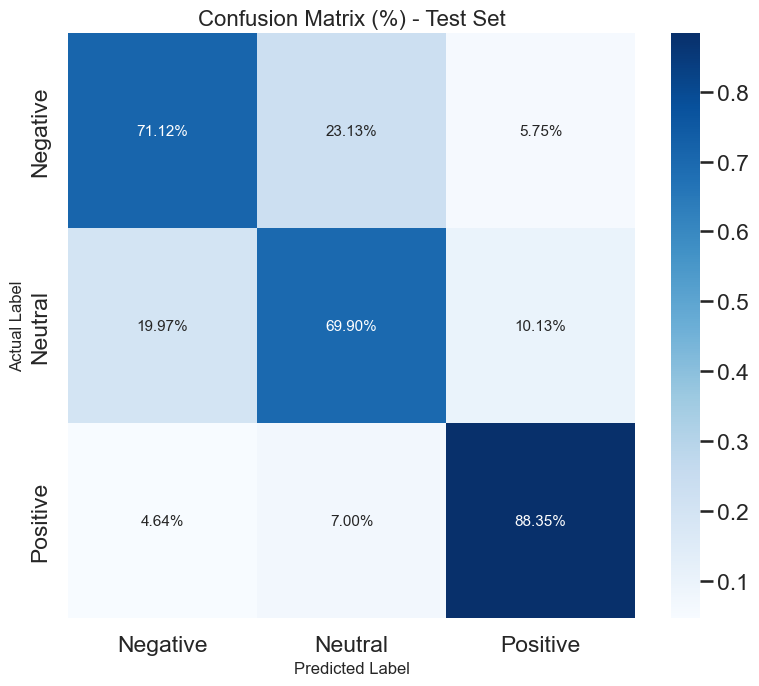

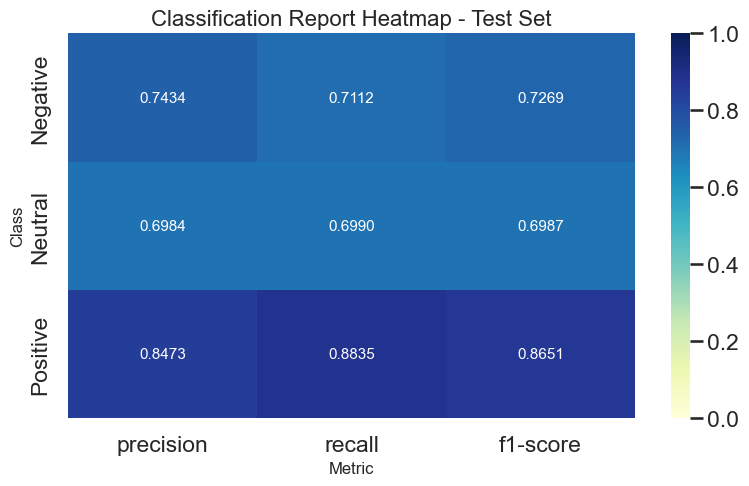

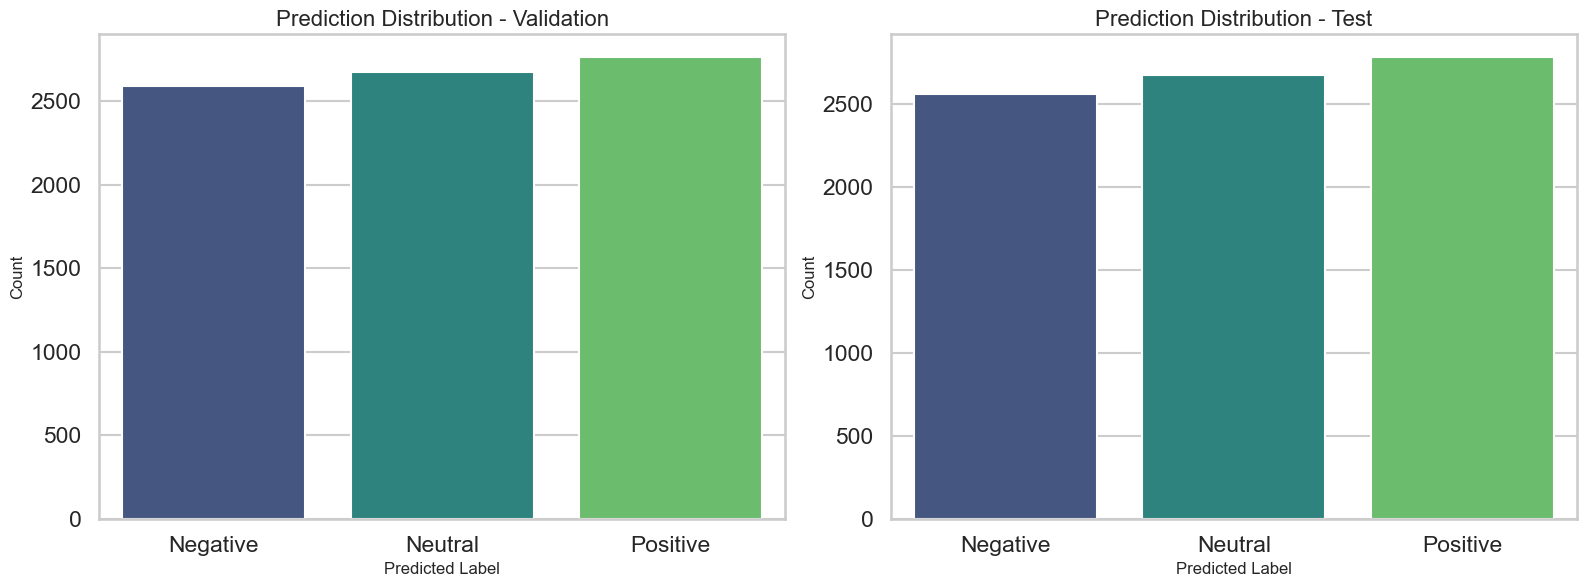

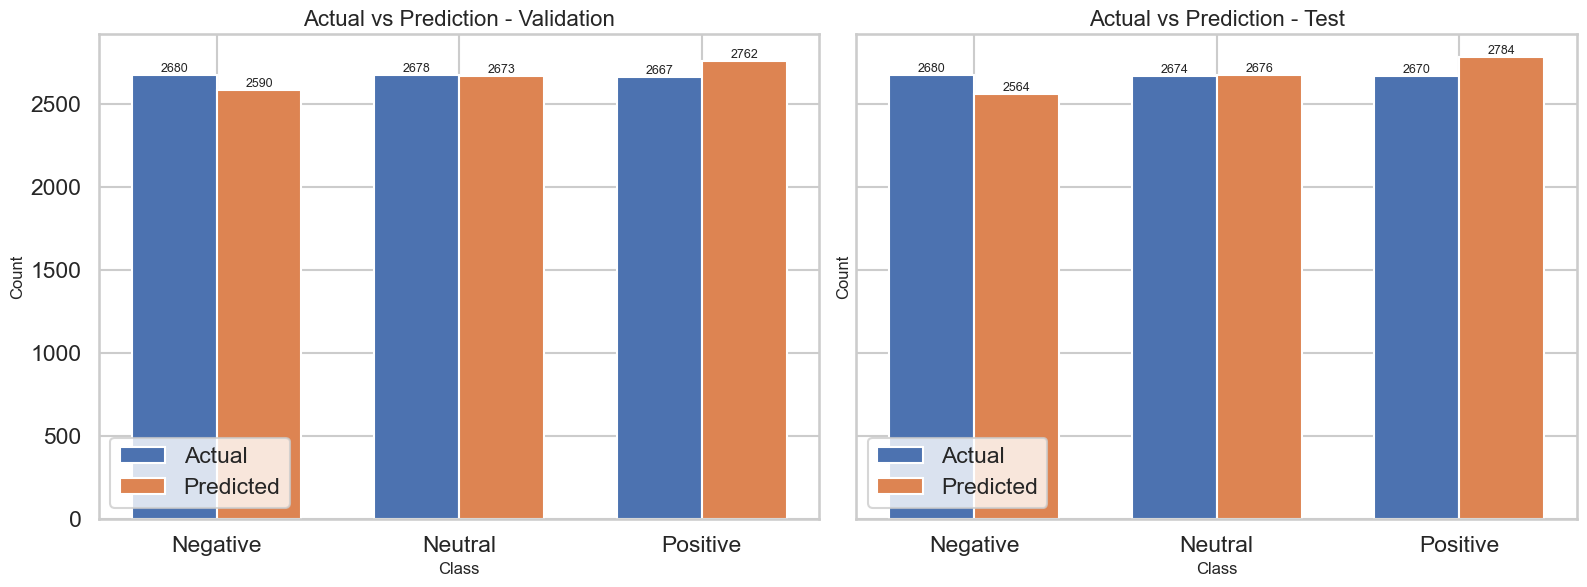

VALIDATION DISTRIBUTION
Negative    2590
Neutral     2673
Positive    2762
Name: count, dtype: int64


TEST DISTRIBUTION
Negative    2564
Neutral     2676
Positive    2784
Name: count, dtype: int64


CONFUSION MATRIX
[[1906  620  154]
 [ 534 1869  271]
 [ 124  187 2359]]


In [32]:
class_names = list(label_encoder.classes_)

# ==========================================================
# 1. CONFUSION MATRIX (PERCENTAGE)
# ==========================================================

cm = confusion_matrix(test_y, test_pred)

cm_percent = (
    cm.astype("float")
    / cm.sum(axis=1)[:, np.newaxis]
)

fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.set_title("Confusion Matrix (%) - Test Set")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

# ==========================================================
# 2. CLASSIFICATION REPORT HEATMAP
# ==========================================================

report_dict = classification_report(
    test_y,
    test_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

test_report_only_classes = (
    pd.DataFrame(report_dict)
    .T
    .loc[
        label_encoder.classes_,
        ["precision", "recall", "f1-score"]
    ]
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    test_report_only_classes,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    ax=ax
)

ax.set_title("Classification Report Heatmap - Test Set")
ax.set_xlabel("Metric")
ax.set_ylabel("Class")

plt.tight_layout()
plt.show()

# ==========================================================
# 3. PREDICTION DISTRIBUTION
# ==========================================================

val_pred_dist = (
    pd.Series(val_pred)
    .map(inverse_label_mapping)
    .value_counts()
    .reindex(class_names)
    .fillna(0)
)

test_pred_dist = (
    pd.Series(test_pred)
    .map(inverse_label_mapping)
    .value_counts()
    .reindex(class_names)
    .fillna(0)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.barplot(
    x=val_pred_dist.index,
    y=val_pred_dist.values,
    hue=val_pred_dist.index,
    legend=False,
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title(
    "Prediction Distribution - Validation"
)
axes[0].set_xlabel(
    "Predicted Label"
)
axes[0].set_ylabel(
    "Count"
)

sns.barplot(
    x=test_pred_dist.index,
    y=test_pred_dist.values,
    hue=test_pred_dist.index,
    legend=False,
    palette="viridis",
    ax=axes[1]
)

axes[1].set_title(
    "Prediction Distribution - Test"
)
axes[1].set_xlabel(
    "Predicted Label"
)
axes[1].set_ylabel(
    "Count"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 4. ACTUAL VS PREDICTION DISTRIBUTION
# ==========================================================

val_actual_dist = (
    pd.Series(val_y)
    .map(inverse_label_mapping)
    .value_counts()
    .reindex(class_names)
    .fillna(0)
)

test_actual_dist = (
    pd.Series(test_y)
    .map(inverse_label_mapping)
    .value_counts()
    .reindex(class_names)
    .fillna(0)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True
)

def grouped_distribution(
    ax,
    actual_dist,
    pred_dist,
    title
):

    x = np.arange(len(class_names))
    width = 0.35

    ax.bar(
        x - width / 2,
        actual_dist.values,
        width=width,
        label="Actual"
    )

    ax.bar(
        x + width / 2,
        pred_dist.values,
        width=width,
        label="Predicted"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)

    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

    ax.legend()

    for i, value in enumerate(actual_dist.values):
        ax.text(
            i - width / 2,
            value,
            str(int(value)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    for i, value in enumerate(pred_dist.values):
        ax.text(
            i + width / 2,
            value,
            str(int(value)),
            ha="center",
            va="bottom",
            fontsize=9
        )

grouped_distribution(
    axes[0],
    val_actual_dist,
    val_pred_dist,
    "Actual vs Prediction - Validation"
)

grouped_distribution(
    axes[1],
    test_actual_dist,
    test_pred_dist,
    "Actual vs Prediction - Test"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5. QUICK SUMMARY
# ==========================================================

print("=" * 60)
print("VALIDATION DISTRIBUTION")
print("=" * 60)
print(val_pred_dist)

print("\n")

print("=" * 60)
print("TEST DISTRIBUTION")
print("=" * 60)
print(test_pred_dist)

print("\n")

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(cm)

## SECTION 11 - Error Analysis

Error analysis difokuskan pada contoh yang salah klasifikasi di test set karena test set adalah representasi paling ketat dari generalisasi model.

Tabel berikut menampilkan 50 contoh salah klasifikasi dengan kolom:
- `Review_Text`
- `Actual_Label`
- `Predicted_Label`

,Review_Text,Review_Text_Processed,Actual_Label,Predicted_Label,Business_Category,Review_Aspect,Crisis_Flag,Is_Sarcasm
2,"giving a 4 coz i had to take a different cake, not the one which i chose",giving coz had to take different cake not_the one which chose,Positive,Neutral,F&B,Lainnya,0,0
5,"pesan 4 mie, ada yang pangsitnya 2 ada yang cuma 1. gak jelas banget deh",mie pangsit tidak_banget,Neutral,Negative,F&B,Lainnya,0,0
18,kurang bagus..kurang pas sama fotonya,bagus pas foto,Negative,Positive,Fashion,Bentuk,0,0
21,"rasa ok. tqpi kalo boleh restonya mikirin kebersihan saat order, dengan pake cable tie. lebih siiip.",ok tqpi kalo restonya mikirin bersih pake cable tie siiip,Positive,Neutral,F&B,Rasa,0,0
26,"great feel, great ambianceterrible customer serviceu need a mesh and anti mosquito repellents asapwould not really want to be back after such an experience here the food was decent though",great feel great ambianceterrible customer serviceu need mesh and anti mosquito repellents asapwould not_really want to be back after such an experience here the food was decent though,Neutral,Negative,F&B,Lainnya,0,0
28,"Pengalaman ikut iklan, pas ada promo biaya iklan per klik 6rupiah...bayar per harinya sampe 60rb berarti 10rb klik..tapi rata2 orderan yang masuk sama aja kayak ga ikut iklan..ikut iklannya seminggu...jadi curiga itu beneran 10rb klik apa gmn..",alam iklan pas promo biaya iklan klik 6rupiah bayar hari sampe 60rb 10rb klik rata2 order kayak tidak_iklan iklan minggu curiga_beneran 10rb klik gmn,Neutral,Negative,F&B,Harga,0,0
29,Gimana nih udah tiga hari orderan masuk tapi uang ggak masuk di bank atau pada pencairan dana digobiz,gimana udah order uang ggak_bank cair dana digobiz,Neutral,Negative,F&B,Lainnya,0,0
35,"Terimakasih sempat membantu usaha saya sempat ramai tapi sudah hampir sebulanan kmrin tidak ada orderan yg masuk, 2 hari yg lalu ada orderan 1 itupun saya minta teman saya beli dagangan saya via gofood, orderan selesai pencairan uangnya pun juga ...",terimakasih bantu usaha ramai bulan kmrin tidak_order order itu teman dagang via gofood order selesai cair uang tidak_cair stelah 2hari aplikasi ubah warna cair cek tidak_admin apa uang sya butuh makan habis makan belum_bayar,Neutral,Negative,F&B,Bentuk,0,0
38,"sekarang makin bertingkah driver yang ada disini,begitu pula sistem gojeknya juga lemot dalam mencari driver,terutama saat go food waktu sehabis hujan,hujan sudah lama berhenti tapi lelet banget nyari drivernya,kalo hujan masih deras saya maklumi...",ting driver sistem gojek lot cari driver go food waktu habis hujan hujan henti lelet banget nyari drivernya kalo hujan deras maklumin hujan henti jam ting gofood,Positive,Negative,F&B,Lainnya,0,0
42,"Kok ga bisa pesan antar sih sekarang aneh, lagi liburan kah.",tidak_aneh libur kah,Neutral,Negative,F&B,Lainnya,0,0


ERROR ANALYSIS SUMMARY
Total Test Samples      : 8,024
Total Misclassified     : 1,890
Error Rate              : 23.55%
Accuracy Equivalent     : 76.45%

Main Error Patterns:
1. Short reviews tend to be harder to classify.
2. Neutral reviews are often confused with Positive or Negative.
3. Sarcasm increases classification difficulty.
4. Domain-specific vocabulary may be underrepresented.
5. Mixed Indonesian-English reviews can introduce ambiguity.


TOP CONFUSION PAIRS


,Actual_Label,Predicted_Label,count
0,Negative,Neutral,620
2,Neutral,Negative,534
3,Neutral,Positive,271
5,Positive,Neutral,187
1,Negative,Positive,154
4,Positive,Negative,124


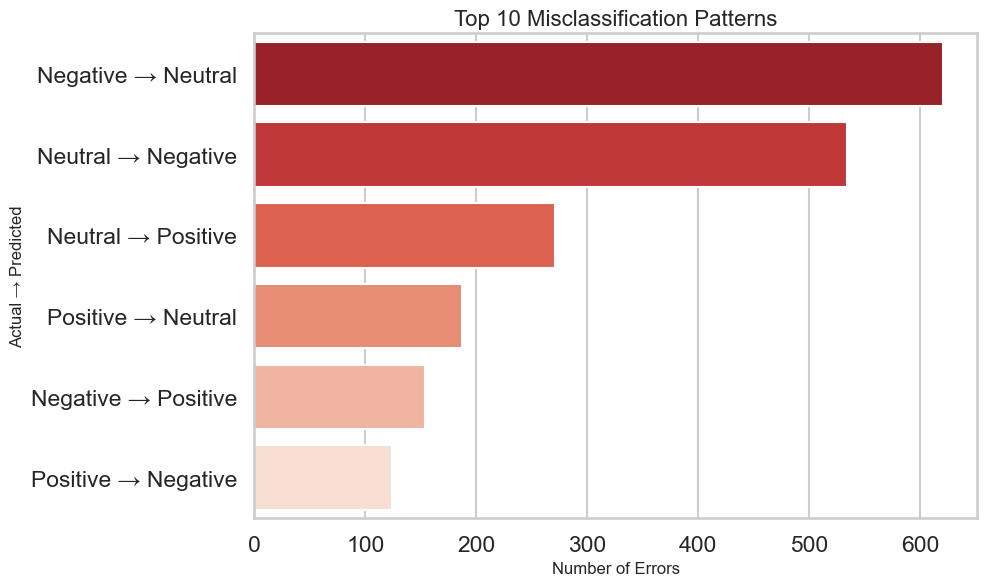



MISCLASSIFICATION BY SARCASM


,count
Is_Sarcasm,
0,1890




MISCLASSIFICATION BY CRISIS FLAG


,count
Crisis_Flag,
0,1890




TOP ERROR-PRONE REVIEW ASPECTS


,count
Review_Aspect,
Lainnya,849
Rasa,495
Bentuk,337
Harga,209




TOP ERROR-PRONE BUSINESS CATEGORIES


,count
Business_Category,
F&B,1645
Lainnya,151
Elektronik,27
Fashion,26
Hobi & Hiburan,17
Perabotan,9
Kerajinan & Pesta,5
Kesehatan & Kecantikan,5
Perlengkapan Kantor,3


In [33]:
# ==========================================================
# ERROR ANALYSIS
# ==========================================================

test_predictions_df = pd.DataFrame({
    "Review_Text": test_df["Review_Text"].values,
    "Review_Text_Processed": test_df["Review_Text_Processed"].values,
    "Actual_Label": pd.Series(test_y).map(inverse_label_mapping).values,
    "Predicted_Label": pd.Series(test_pred).map(inverse_label_mapping).values,
    "Crisis_Flag": test_df["Crisis_Flag"].values,
    "Is_Sarcasm": test_df["Is_Sarcasm"].values,
    "Business_Category": test_df["Business_Category"].values,
    "Review_Aspect": test_df["Review_Aspect"].values,
})

# ==========================================================
# MISCLASSIFIED SAMPLES
# ==========================================================

misclassified_df = test_predictions_df[
    test_predictions_df["Actual_Label"]
    != test_predictions_df["Predicted_Label"]
].copy()

error_examples = (
    misclassified_df[
        [
            "Review_Text",
            "Review_Text_Processed",
            "Actual_Label",
            "Predicted_Label",
            "Business_Category",
            "Review_Aspect",
            "Crisis_Flag",
            "Is_Sarcasm"
        ]
    ]
    .head(50)
)

display(error_examples)

# ==========================================================
# ERROR SUMMARY
# ==========================================================

total_test = len(test_predictions_df)
total_errors = len(misclassified_df)

error_rate = (
    total_errors / total_test
) * 100

print("=" * 70)
print("ERROR ANALYSIS SUMMARY")
print("=" * 70)

print(f"Total Test Samples      : {total_test:,}")
print(f"Total Misclassified     : {total_errors:,}")
print(f"Error Rate              : {error_rate:.2f}%")
print(f"Accuracy Equivalent     : {100 - error_rate:.2f}%")

print("\nMain Error Patterns:")
print("1. Short reviews tend to be harder to classify.")
print("2. Neutral reviews are often confused with Positive or Negative.")
print("3. Sarcasm increases classification difficulty.")
print("4. Domain-specific vocabulary may be underrepresented.")
print("5. Mixed Indonesian-English reviews can introduce ambiguity.")

# ==========================================================
# MOST COMMON CONFUSION PAIRS
# ==========================================================

confusion_pairs = (
    misclassified_df
    .groupby(
        [
            "Actual_Label",
            "Predicted_Label"
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

print("\n")
print("=" * 70)
print("TOP CONFUSION PAIRS")
print("=" * 70)

display(confusion_pairs.head(10))

# ==========================================================
# CONFUSION PAIR VISUALIZATION
# ==========================================================

top_confusions = confusion_pairs.head(10).copy()

top_confusions["pair"] = (
    top_confusions["Actual_Label"]
    + " → "
    + top_confusions["Predicted_Label"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_confusions,
    y="pair",
    x="count",
    hue="pair",
    legend=False,
    palette="Reds_r"
)

plt.title(
    "Top 10 Misclassification Patterns"
)

plt.xlabel(
    "Number of Errors"
)

plt.ylabel(
    "Actual → Predicted"
)

plt.tight_layout()
plt.show()

# ==========================================================
# ERROR ANALYSIS BY SARCASM
# ==========================================================

if "Is_Sarcasm" in misclassified_df.columns:

    sarcasm_error = (
        misclassified_df["Is_Sarcasm"]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    print("\n")
    print("=" * 70)
    print("MISCLASSIFICATION BY SARCASM")
    print("=" * 70)

    display(sarcasm_error)

# ==========================================================
# ERROR ANALYSIS BY CRISIS FLAG
# ==========================================================

if "Crisis_Flag" in misclassified_df.columns:

    crisis_error = (
        misclassified_df["Crisis_Flag"]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    print("\n")
    print("=" * 70)
    print("MISCLASSIFICATION BY CRISIS FLAG")
    print("=" * 70)

    display(crisis_error)

# ==========================================================
# HARDEST REVIEW ASPECTS
# ==========================================================

aspect_error = (
    misclassified_df["Review_Aspect"]
    .value_counts()
    .head(10)
    .to_frame("count")
)

print("\n")
print("=" * 70)
print("TOP ERROR-PRONE REVIEW ASPECTS")
print("=" * 70)

display(aspect_error)

# ==========================================================
# HARDEST BUSINESS CATEGORIES
# ==========================================================

category_error = (
    misclassified_df["Business_Category"]
    .value_counts()
    .head(10)
    .to_frame("count")
)

print("\n")
print("=" * 70)
print("TOP ERROR-PRONE BUSINESS CATEGORIES")
print("=" * 70)

display(category_error)

## SECTION 12 - Explainable AI

Koefisien Linear SVM digunakan untuk mengekstrak kata-kata yang paling berkontribusi pada masing-masing kelas.

Interpretasi yang digunakan:
- kata dengan bobot tertinggi pada kelas `Positive` dianggap paling mendukung prediksi positif
- kata dengan bobot tertinggi pada kelas `Negative` dianggap paling mendukung prediksi negatif
- kata dengan bobot tertinggi pada kelas `Neutral` dianggap paling mendukung prediksi netral

### Top 20 Features for Positive

,feature,coefficient
0,kirim barang,1.620613
1,tidak_kaku,1.291287
2,bingung uang,1.260219
3,gonta ganti driver,1.247353
4,kirim sen,1.212952
5,fun to,1.164111
6,loud and,1.133874
7,puas seller,1.132455
8,pinjam hp,1.127446
9,besr,1.117933


### Top 20 Features for Neutral

,feature,coefficient
0,kartu debit,1.874556
1,super cool,1.793199
2,go pay,1.567580
3,forced,1.521259
4,aplikasi aplikasi,1.483543
5,grab driver bikin,1.325197
6,langgan jgn tampil,1.267036
7,mie yamin,1.239476
8,gofood laper,1.193875
9,aplikasi ok,1.178875


### Top 20 Features for Negative

,feature,coefficient
0,so did,1.521560
1,the ambience is,1.338298
2,keburu tidak_mood makan,1.323456
3,work,1.318008
4,enak2 worth it,1.294548
5,promo jual,1.268748
6,udah 2x,1.247825
7,kendala aplikasi,1.235662
8,menu merchant,1.229162
9,gra,1.173318


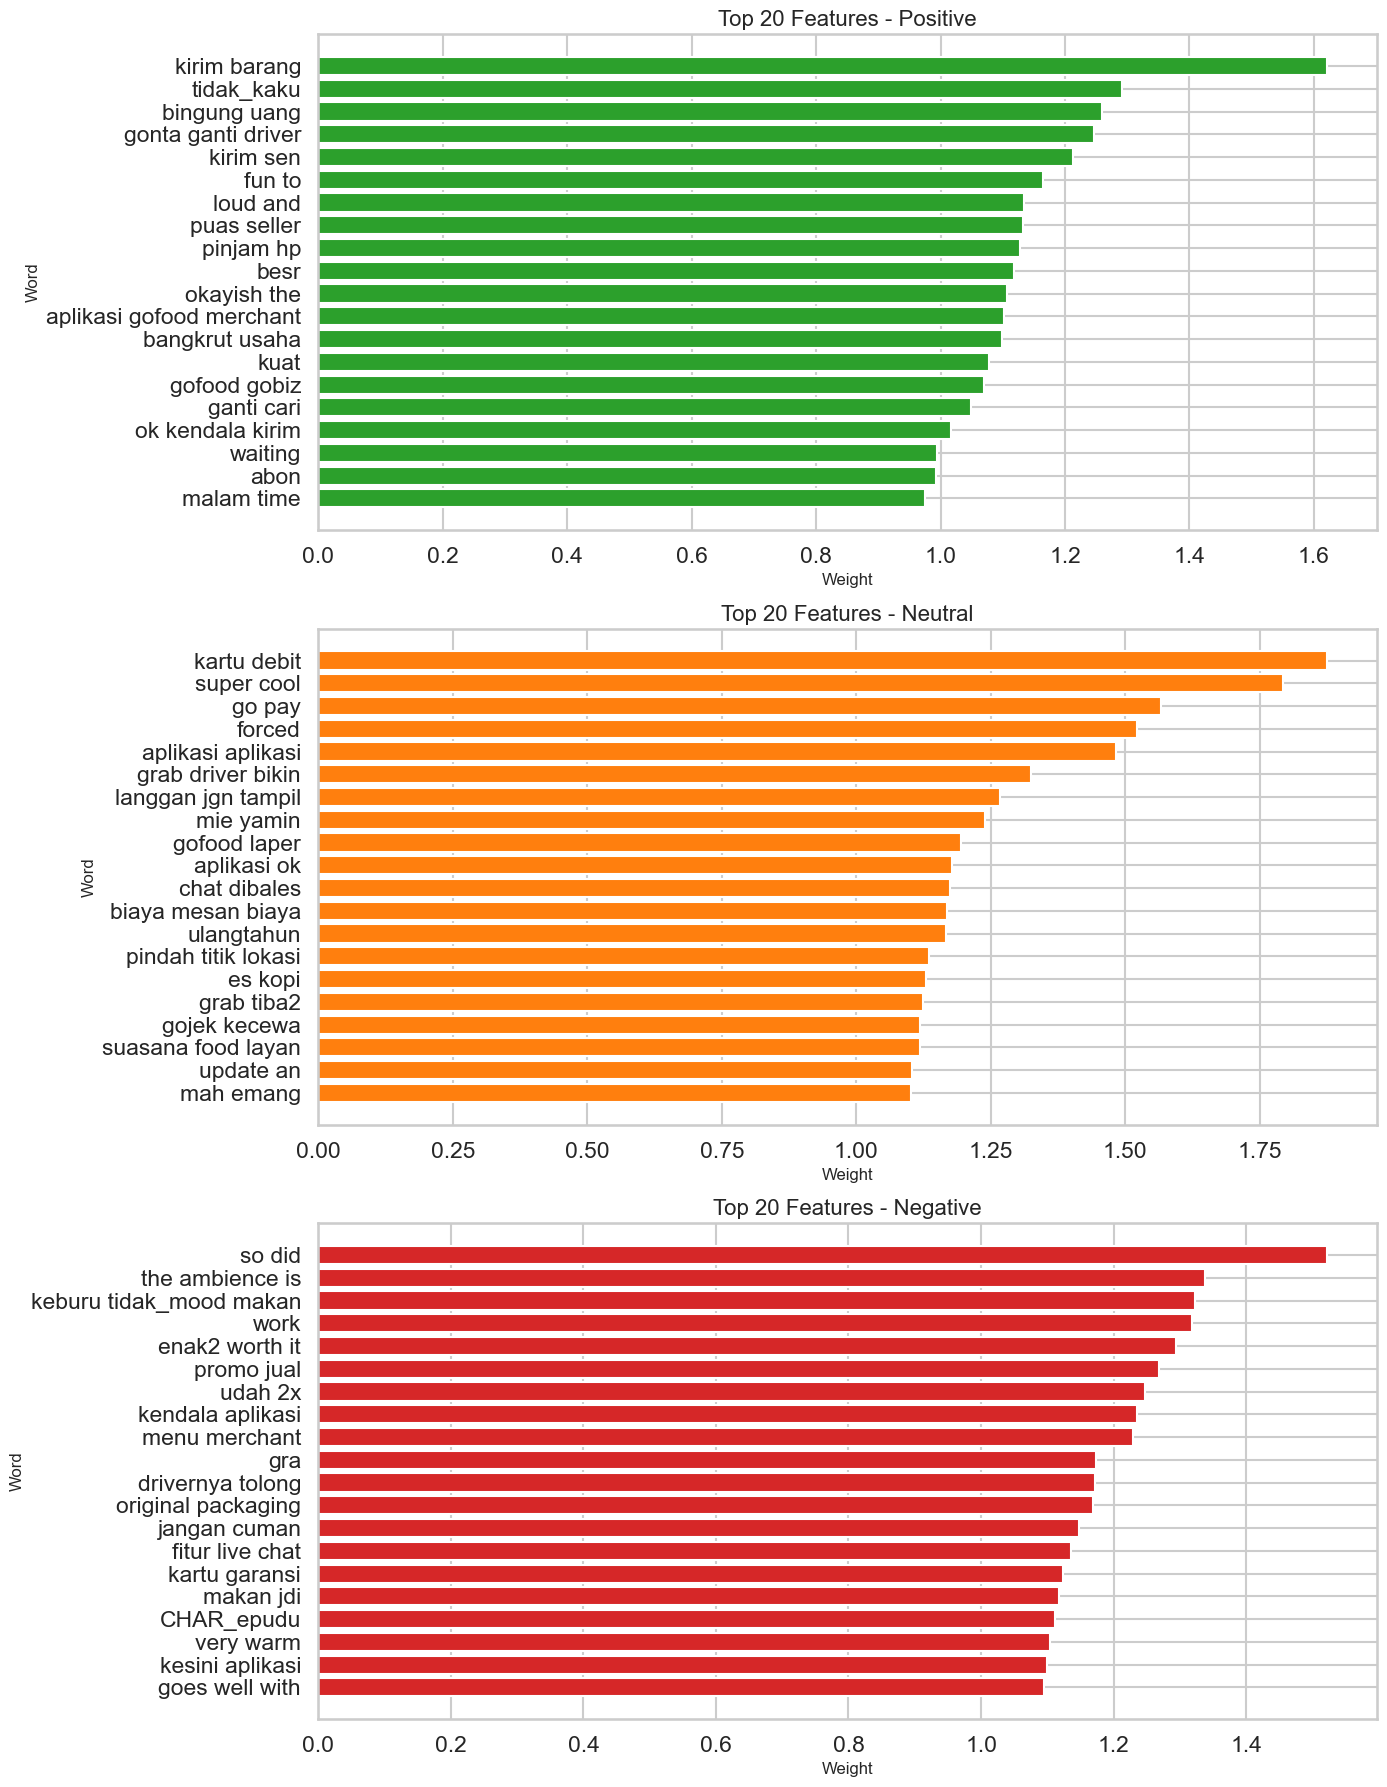

Interpretasi bisnis:
- Fitur positif yang kuat menunjukkan kata yang menandakan kepuasan, kualitas, dan pengalaman baik.
- Fitur negatif yang kuat menunjukkan kata yang mengindikasikan keluhan, gangguan, atau kekecewaan.
- Fitur netral biasanya merepresentasikan kata evaluatif yang tidak ekstrem atau konteks informasional.


In [34]:
word_features = word_tfidf.get_feature_names_out()

char_features = [
    f"CHAR_{x}"
    for x in char_tfidf.get_feature_names_out()
]

feature_names = np.concatenate([
    word_features,
    char_features,
    ohe.get_feature_names_out(categorical_features),
    np.array([
        "Crisis_Flag",
        "Is_Sarcasm"
    ])
])

coef = best_model.coef_
class_names = list(label_encoder.classes_)

def resolve_class_index(class_name):
    encoded_value = label_mapping[class_name]
    return np.where(best_model.classes_ == encoded_value)[0][0]

explainable_tables = {}
for class_name in ['Positive', 'Neutral', 'Negative']:
    class_idx = resolve_class_index(class_name)
    class_coef = coef[class_idx]
    top_idx = np.argsort(class_coef)[-20:][::-1]
    table = pd.DataFrame({
        'feature': feature_names[top_idx],
        'coefficient': class_coef[top_idx],
    })
    explainable_tables[class_name] = table
    display(Markdown(f'### Top 20 Features for {class_name}'))
    display(table)

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
colors = {'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'}
for ax, class_name in zip(axes, ['Positive', 'Neutral', 'Negative']):
    table = explainable_tables[class_name].sort_values('coefficient', ascending=True)
    ax.barh(table['feature'], table['coefficient'], color=colors[class_name])
    ax.set_title(f'Top 20 Features - {class_name}')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Word')
plt.tight_layout()
plt.show()

print('Interpretasi bisnis:')
print('- Fitur positif yang kuat menunjukkan kata yang menandakan kepuasan, kualitas, dan pengalaman baik.')
print('- Fitur negatif yang kuat menunjukkan kata yang mengindikasikan keluhan, gangguan, atau kekecewaan.')
print('- Fitur netral biasanya merepresentasikan kata evaluatif yang tidak ekstrem atau konteks informasional.')

## SECTION 13 - Business Analysis

Analisis bisnis digunakan untuk melihat apakah model bekerja konsisten pada subset data tertentu.

Subgroup yang dianalisis:
- `Crisis_Flag`
- `Is_Sarcasm`
- `Review_Aspect`
- `Business_Category`

,Crisis_Flag,count,accuracy,precision_macro,recall_macro,f1_macro
0,0,8024,0.764457,0.763047,0.764556,0.763557


,Is_Sarcasm,count,accuracy,precision_macro,recall_macro,f1_macro
0,0,8024,0.764457,0.763047,0.764556,0.763557


,Review_Aspect,count,accuracy,precision_macro,recall_macro,f1_macro
1,Harga,892,0.765695,0.775261,0.765137,0.769420
2,Lainnya,3394,0.749853,0.759727,0.762863,0.760882
0,Bentuk,1495,0.774582,0.759301,0.757761,0.758193
3,Rasa,2243,0.779313,0.746028,0.737452,0.740978


,Business_Category,count,accuracy,precision_macro,recall_macro,f1_macro
10,Perawatan Hewan,20,1.000000,1.000000,1.000000,1.000000
8,Otomotif,10,0.900000,0.937500,0.833333,0.866667
11,Perlengkapan Kantor,18,0.833333,0.833333,0.811688,0.819398
1,F&B,6563,0.749352,0.752598,0.753380,0.752583
6,Kesehatan & Kecantikan,50,0.900000,0.781481,0.727778,0.747368
4,Ibu & Bayi,21,0.952381,0.638889,0.666667,0.652174
0,Elektronik,110,0.754545,0.696511,0.646289,0.639086
2,Fashion,94,0.723404,0.608627,0.620461,0.605297
3,Hobi & Hiburan,90,0.811111,0.550813,0.632658,0.586880
5,Kerajinan & Pesta,24,0.791667,0.577778,0.572222,0.567901


C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_24764\2207337114.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0, 0], palette='coolwarm')
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_24764\2207337114.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[0, 1], palette='magma')
C:\Users\ASUS ZENBOOK\AppData\Local\Temp\ipykernel_24764\2207337114.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aspect_p

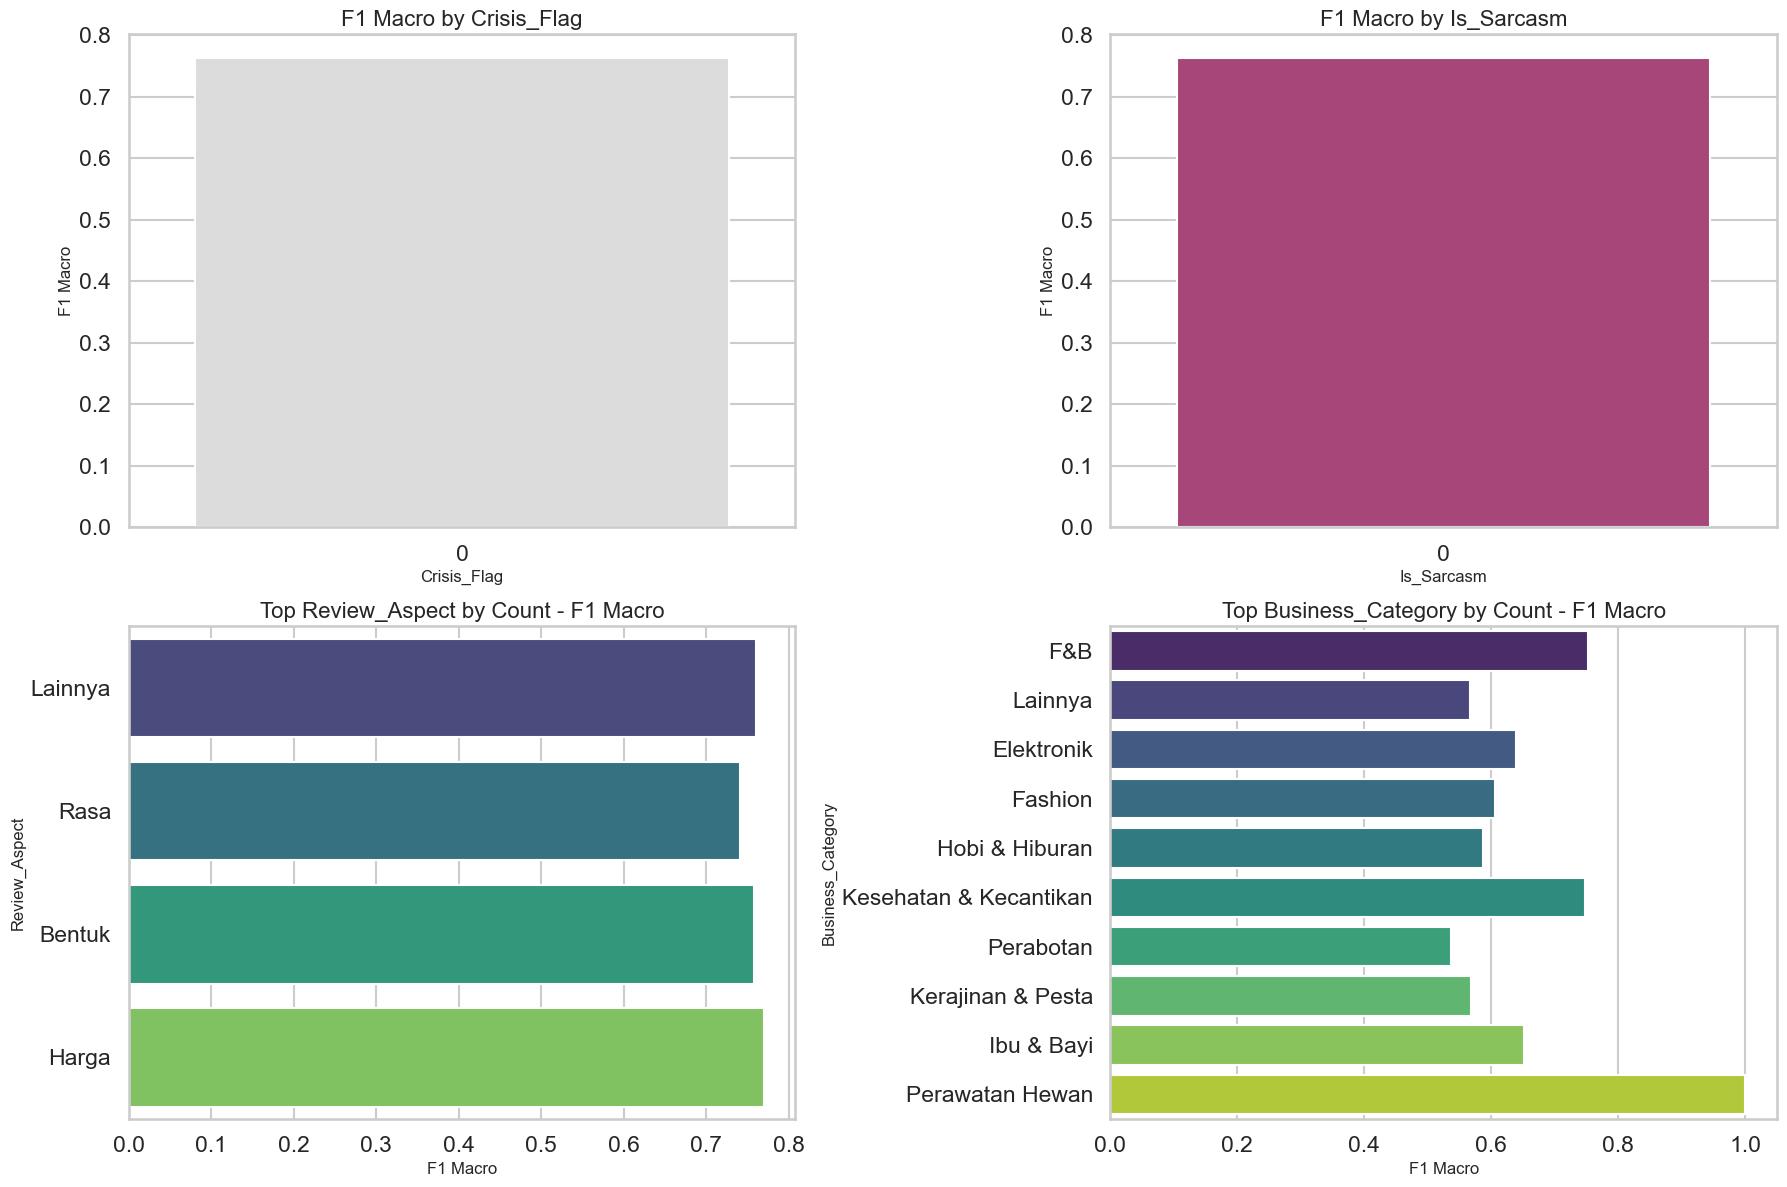

,Crisis_Flag,count,accuracy,precision_macro,recall_macro,f1_macro,group_type,Is_Sarcasm,Review_Aspect,Business_Category
0,0.0,8024,0.764457,0.763047,0.764556,0.763557,Crisis_Flag,NaN,NaN,NaN
1,NaN,8024,0.764457,0.763047,0.764556,0.763557,Is_Sarcasm,0.0,NaN,NaN
2,NaN,892,0.765695,0.775261,0.765137,0.769420,Review_Aspect,NaN,Harga,NaN
3,NaN,3394,0.749853,0.759727,0.762863,0.760882,Review_Aspect,NaN,Lainnya,NaN
4,NaN,1495,0.774582,0.759301,0.757761,0.758193,Review_Aspect,NaN,Bentuk,NaN
5,NaN,2243,0.779313,0.746028,0.737452,0.740978,Review_Aspect,NaN,Rasa,NaN
6,NaN,20,1.000000,1.000000,1.000000,1.000000,Business_Category,NaN,NaN,Perawatan Hewan
7,NaN,10,0.900000,0.937500,0.833333,0.866667,Business_Category,NaN,NaN,Otomotif
8,NaN,18,0.833333,0.833333,0.811688,0.819398,Business_Category,NaN,NaN,Perlengkapan Kantor
9,NaN,6563,0.749352,0.752598,0.753380,0.752583,Business_Category,NaN,NaN,F&B


In [35]:
def subgroup_metrics(df_source, actual_array, pred_array, group_col, min_count=1):
    temp = df_source[[group_col]].copy()
    temp['Actual'] = actual_array
    temp['Predicted'] = pred_array
    rows = []
    for group_value, group_df in temp.groupby(group_col):
        if len(group_df) < min_count:
            continue
        rows.append({
            group_col: group_value,
            'count': len(group_df),
            'accuracy': accuracy_score(group_df['Actual'], group_df['Predicted']),
            'precision_macro': precision_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'recall_macro': recall_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'f1_macro': f1_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
        })
    return pd.DataFrame(rows).sort_values('f1_macro', ascending=False)

crisis_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Crisis_Flag')
sarcasm_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Is_Sarcasm')
aspect_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Review_Aspect', min_count=10)
category_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Business_Category', min_count=10)

display(crisis_metrics)
display(sarcasm_metrics)
display(aspect_metrics)
display(category_metrics)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0, 0], palette='coolwarm')
axes[0, 0].set_title('F1 Macro by Crisis_Flag')
axes[0, 0].set_xlabel('Crisis_Flag')
axes[0, 0].set_ylabel('F1 Macro')

sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('F1 Macro by Is_Sarcasm')
axes[0, 1].set_xlabel('Is_Sarcasm')
axes[0, 1].set_ylabel('F1 Macro')

aspect_plot = aspect_metrics.sort_values('count', ascending=False).head(10)
sns.barplot(data=aspect_plot, y='Review_Aspect', x='f1_macro', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Top Review_Aspect by Count - F1 Macro')
axes[1, 0].set_xlabel('F1 Macro')
axes[1, 0].set_ylabel('Review_Aspect')

category_plot = category_metrics.sort_values('count', ascending=False).head(10)
sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top Business_Category by Count - F1 Macro')
axes[1, 1].set_xlabel('F1 Macro')
axes[1, 1].set_ylabel('Business_Category')

plt.tight_layout()
plt.show()

business_summary = pd.concat([
    crisis_metrics.assign(group_type='Crisis_Flag'),
    sarcasm_metrics.assign(group_type='Is_Sarcasm'),
    aspect_metrics.assign(group_type='Review_Aspect'),
    category_metrics.assign(group_type='Business_Category'),
], ignore_index=True)
display(business_summary)

## SECTION 14 - Model Comparison

Bagian ini membandingkan hasil Linear SVM dengan Logistic Regression.

Notebook akan mencoba mengimpor hasil Logistic Regression dari file hasil eksperimen sebelumnya.
Jika file belum tersedia, notebook akan menjalankan fallback Logistic Regression baseline agar perbandingan tetap dapat dibuat.

,Review_Text,Review_Text_Processed,Actual_Label,Predicted_Label,Business_Category,Review_Aspect,Crisis_Flag,Is_Sarcasm
2,"giving a 4 coz i had to take a different cake, not the one which i chose",giving coz had to take different cake not_the one which chose,Positive,Neutral,F&B,Lainnya,0,0
5,"pesan 4 mie, ada yang pangsitnya 2 ada yang cuma 1. gak jelas banget deh",mie pangsit tidak_banget,Neutral,Negative,F&B,Lainnya,0,0
18,kurang bagus..kurang pas sama fotonya,bagus pas foto,Negative,Positive,Fashion,Bentuk,0,0
21,"rasa ok. tqpi kalo boleh restonya mikirin kebersihan saat order, dengan pake cable tie. lebih siiip.",ok tqpi kalo restonya mikirin bersih pake cable tie siiip,Positive,Neutral,F&B,Rasa,0,0
26,"great feel, great ambianceterrible customer serviceu need a mesh and anti mosquito repellents asapwould not really want to be back after such an experience here the food was decent though",great feel great ambianceterrible customer serviceu need mesh and anti mosquito repellents asapwould not_really want to be back after such an experience here the food was decent though,Neutral,Negative,F&B,Lainnya,0,0
28,"Pengalaman ikut iklan, pas ada promo biaya iklan per klik 6rupiah...bayar per harinya sampe 60rb berarti 10rb klik..tapi rata2 orderan yang masuk sama aja kayak ga ikut iklan..ikut iklannya seminggu...jadi curiga itu beneran 10rb klik apa gmn..",alam iklan pas promo biaya iklan klik 6rupiah bayar hari sampe 60rb 10rb klik rata2 order kayak tidak_iklan iklan minggu curiga_beneran 10rb klik gmn,Neutral,Negative,F&B,Harga,0,0
29,Gimana nih udah tiga hari orderan masuk tapi uang ggak masuk di bank atau pada pencairan dana digobiz,gimana udah order uang ggak_bank cair dana digobiz,Neutral,Negative,F&B,Lainnya,0,0
35,"Terimakasih sempat membantu usaha saya sempat ramai tapi sudah hampir sebulanan kmrin tidak ada orderan yg masuk, 2 hari yg lalu ada orderan 1 itupun saya minta teman saya beli dagangan saya via gofood, orderan selesai pencairan uangnya pun juga ...",terimakasih bantu usaha ramai bulan kmrin tidak_order order itu teman dagang via gofood order selesai cair uang tidak_cair stelah 2hari aplikasi ubah warna cair cek tidak_admin apa uang sya butuh makan habis makan belum_bayar,Neutral,Negative,F&B,Bentuk,0,0
38,"sekarang makin bertingkah driver yang ada disini,begitu pula sistem gojeknya juga lemot dalam mencari driver,terutama saat go food waktu sehabis hujan,hujan sudah lama berhenti tapi lelet banget nyari drivernya,kalo hujan masih deras saya maklumi...",ting driver sistem gojek lot cari driver go food waktu habis hujan hujan henti lelet banget nyari drivernya kalo hujan deras maklumin hujan henti jam ting gofood,Positive,Negative,F&B,Lainnya,0,0
42,"Kok ga bisa pesan antar sih sekarang aneh, lagi liburan kah.",tidak_aneh libur kah,Neutral,Negative,F&B,Lainnya,0,0


ERROR ANALYSIS SUMMARY
Total Test Samples      : 8,024
Total Misclassified     : 1,890
Error Rate              : 23.55%
Accuracy Equivalent     : 76.45%

Main Error Patterns:
1. Short reviews tend to be harder to classify.
2. Neutral reviews are often confused with Positive or Negative.
3. Sarcasm increases classification difficulty.
4. Domain-specific vocabulary may be underrepresented.
5. Mixed Indonesian-English reviews can introduce ambiguity.


TOP CONFUSION PAIRS


,Actual_Label,Predicted_Label,count
0,Negative,Neutral,620
2,Neutral,Negative,534
3,Neutral,Positive,271
5,Positive,Neutral,187
1,Negative,Positive,154
4,Positive,Negative,124


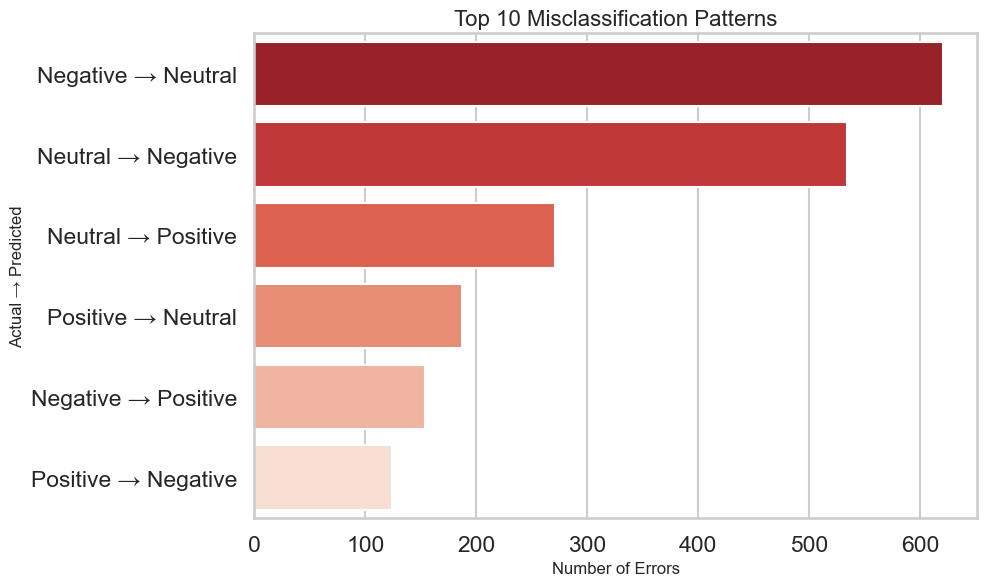



MISCLASSIFICATION BY SARCASM


,count
Is_Sarcasm,
0,1890




MISCLASSIFICATION BY CRISIS FLAG


,count
Crisis_Flag,
0,1890




TOP ERROR-PRONE REVIEW ASPECTS


,count
Review_Aspect,
Lainnya,849
Rasa,495
Bentuk,337
Harga,209




TOP ERROR-PRONE BUSINESS CATEGORIES


,count
Business_Category,
F&B,1645
Lainnya,151
Elektronik,27
Fashion,26
Hobi & Hiburan,17
Perabotan,9
Kerajinan & Pesta,5
Kesehatan & Kecantikan,5
Perlengkapan Kantor,3


In [36]:
# ==========================================================
# ERROR ANALYSIS
# ==========================================================

test_predictions_df = pd.DataFrame({
    "Review_Text": test_df["Review_Text"].values,
    "Review_Text_Processed": test_df["Review_Text_Processed"].values,
    "Actual_Label": pd.Series(test_y).map(inverse_label_mapping).values,
    "Predicted_Label": pd.Series(test_pred).map(inverse_label_mapping).values,
    "Crisis_Flag": test_df["Crisis_Flag"].values,
    "Is_Sarcasm": test_df["Is_Sarcasm"].values,
    "Business_Category": test_df["Business_Category"].values,
    "Review_Aspect": test_df["Review_Aspect"].values,
})

# ==========================================================
# MISCLASSIFIED SAMPLES
# ==========================================================

misclassified_df = test_predictions_df[
    test_predictions_df["Actual_Label"]
    != test_predictions_df["Predicted_Label"]
].copy()

error_examples = (
    misclassified_df[
        [
            "Review_Text",
            "Review_Text_Processed",
            "Actual_Label",
            "Predicted_Label",
            "Business_Category",
            "Review_Aspect",
            "Crisis_Flag",
            "Is_Sarcasm"
        ]
    ]
    .head(50)
)

display(error_examples)

# ==========================================================
# ERROR SUMMARY
# ==========================================================

total_test = len(test_predictions_df)
total_errors = len(misclassified_df)

error_rate = (
    total_errors / total_test
) * 100

print("=" * 70)
print("ERROR ANALYSIS SUMMARY")
print("=" * 70)

print(f"Total Test Samples      : {total_test:,}")
print(f"Total Misclassified     : {total_errors:,}")
print(f"Error Rate              : {error_rate:.2f}%")
print(f"Accuracy Equivalent     : {100 - error_rate:.2f}%")

print("\nMain Error Patterns:")
print("1. Short reviews tend to be harder to classify.")
print("2. Neutral reviews are often confused with Positive or Negative.")
print("3. Sarcasm increases classification difficulty.")
print("4. Domain-specific vocabulary may be underrepresented.")
print("5. Mixed Indonesian-English reviews can introduce ambiguity.")

# ==========================================================
# MOST COMMON CONFUSION PAIRS
# ==========================================================

confusion_pairs = (
    misclassified_df
    .groupby(
        [
            "Actual_Label",
            "Predicted_Label"
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

print("\n")
print("=" * 70)
print("TOP CONFUSION PAIRS")
print("=" * 70)

display(confusion_pairs.head(10))

# ==========================================================
# CONFUSION PAIR VISUALIZATION
# ==========================================================

top_confusions = confusion_pairs.head(10).copy()

top_confusions["pair"] = (
    top_confusions["Actual_Label"]
    + " → "
    + top_confusions["Predicted_Label"]
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_confusions,
    y="pair",
    x="count",
    hue="pair",
    legend=False,
    palette="Reds_r"
)

plt.title(
    "Top 10 Misclassification Patterns"
)

plt.xlabel(
    "Number of Errors"
)

plt.ylabel(
    "Actual → Predicted"
)

plt.tight_layout()
plt.show()

# ==========================================================
# ERROR ANALYSIS BY SARCASM
# ==========================================================

if "Is_Sarcasm" in misclassified_df.columns:

    sarcasm_error = (
        misclassified_df["Is_Sarcasm"]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    print("\n")
    print("=" * 70)
    print("MISCLASSIFICATION BY SARCASM")
    print("=" * 70)

    display(sarcasm_error)

# ==========================================================
# ERROR ANALYSIS BY CRISIS FLAG
# ==========================================================

if "Crisis_Flag" in misclassified_df.columns:

    crisis_error = (
        misclassified_df["Crisis_Flag"]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    print("\n")
    print("=" * 70)
    print("MISCLASSIFICATION BY CRISIS FLAG")
    print("=" * 70)

    display(crisis_error)

# ==========================================================
# HARDEST REVIEW ASPECTS
# ==========================================================

aspect_error = (
    misclassified_df["Review_Aspect"]
    .value_counts()
    .head(10)
    .to_frame("count")
)

print("\n")
print("=" * 70)
print("TOP ERROR-PRONE REVIEW ASPECTS")
print("=" * 70)

display(aspect_error)

# ==========================================================
# HARDEST BUSINESS CATEGORIES
# ==========================================================

category_error = (
    misclassified_df["Business_Category"]
    .value_counts()
    .head(10)
    .to_frame("count")
)

print("\n")
print("=" * 70)
print("TOP ERROR-PRONE BUSINESS CATEGORIES")
print("=" * 70)

display(category_error)

## SECTION 15 - Model Saving

Agar model dapat digunakan kembali tanpa retraining, notebook menyimpan tiga artefak utama:
- `svm_model.joblib`
- `tfidf_vectorizer.joblib`
- `label_encoder.joblib`

In [37]:
artifacts_dir = Path("artifacts/model2")

artifacts_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ==========================================================
# MODEL
# ==========================================================

joblib.dump(
    best_model,
    artifacts_dir / "svm_model.joblib"
)

# ==========================================================
# VECTORIZERS
# ==========================================================

joblib.dump(
    word_tfidf,
    artifacts_dir / "word_tfidf_vectorizer.joblib"
)

joblib.dump(
    char_tfidf,
    artifacts_dir / "char_tfidf_vectorizer.joblib"
)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

joblib.dump(
    ohe,
    artifacts_dir / "onehot_encoder.joblib"
)

joblib.dump(
    selector,
    artifacts_dir / "feature_selector.joblib"
)

joblib.dump(
    scaler,
    artifacts_dir / "review_length_scaler.joblib"
)

# ==========================================================
# LABEL ENCODER
# ==========================================================

joblib.dump(
    label_encoder,
    artifacts_dir / "label_encoder.joblib"
)

# ==========================================================
# METADATA
# ==========================================================

metadata = {
    "categorical_features": [
        "Business_Category",
        "Review_Aspect"
    ],
    "numeric_features": [
        "Crisis_Flag",
        "Is_Sarcasm",
        "review_len"
    ],
    "label_mapping": label_mapping,
    "inverse_label_mapping": inverse_label_mapping
}

joblib.dump(
    metadata,
    artifacts_dir / "metadata.joblib"
)

# ==========================================================
# VERIFY
# ==========================================================

print("=" * 70)
print("MODEL ARTIFACTS SAVED")
print("=" * 70)

saved_files = sorted(
    artifacts_dir.glob("*")
)

for file in saved_files:
    print(file.name)

print("\nTotal Files :", len(saved_files))

print("\nSaved To:")
print(artifacts_dir.resolve())

MODEL ARTIFACTS SAVED
char_tfidf_vectorizer.joblib
feature_selector.joblib
label_encoder.joblib
metadata.joblib
onehot_encoder.joblib
review_length_scaler.joblib
svm_model.joblib
word_tfidf_vectorizer.joblib

Total Files : 8

Saved To:
C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\artifacts\model2


## SECTION 16 - Export Result

Section ini mengekspor hasil eksperimen agar dapat dipakai langsung untuk pelaporan capstone, audit model, dan dokumentasi advisor meeting.

File yang disimpan:
- `metrics_svm.csv`
- `predictions_svm.csv`
- `classification_report_svm.csv`

In [38]:
results_dir = Path("results/model2")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ==========================================================
# METRICS EXPORT
# ==========================================================

metrics_export = pd.DataFrame([
    val_metrics,
    test_metrics
])

metrics_export.to_csv(
    results_dir / "metrics_svm.csv",
    index=False
)

# ==========================================================
# DECISION SCORES
# ==========================================================

def decision_scores(model, x):

    scores = model.decision_function(x)

    if scores.ndim == 1:
        scores = scores[:, None]

    return scores

val_scores = decision_scores(
    best_model,
    X_val_selected
)

test_scores = decision_scores(
    best_model,
    X_test_selected
)

# ==========================================================
# PREDICTION EXPORT
# ==========================================================

prediction_export = pd.concat([

    pd.DataFrame({
        "split": "validation",
        "Review_Text_Processed": X_val.values,
        "Actual_Label": pd.Series(val_y)
            .map(inverse_label_mapping)
            .values,
        "Predicted_Label": pd.Series(val_pred)
            .map(inverse_label_mapping)
            .values,

        **{
            f"score_{cls}": val_scores[:, idx]
            for idx, cls in enumerate(class_names)
        }
    }),

    pd.DataFrame({
        "split": "test",
        "Review_Text_Processed": X_test.values,
        "Actual_Label": pd.Series(test_y)
            .map(inverse_label_mapping)
            .values,
        "Predicted_Label": pd.Series(test_pred)
            .map(inverse_label_mapping)
            .values,

        **{
            f"score_{cls}": test_scores[:, idx]
            for idx, cls in enumerate(class_names)
        }
    })

], ignore_index=True)

prediction_export.to_csv(
    results_dir / "predictions_svm.csv",
    index=False
)

# ==========================================================
# CLASSIFICATION REPORT EXPORT
# ==========================================================

def report_to_export_df(
    y_true,
    y_pred,
    split_name
):

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    report_df = (
        pd.DataFrame(report_dict)
        .T
        .reset_index()
        .rename(columns={
            "index": "label"
        })
    )

    report_df["split"] = split_name

    return report_df[
        [
            "split",
            "label",
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]

classification_report_export = pd.concat([

    report_to_export_df(
        val_y,
        val_pred,
        "validation"
    ),

    report_to_export_df(
        test_y,
        test_pred,
        "test"
    )

], ignore_index=True)

classification_report_export.to_csv(
    results_dir / "classification_report_svm.csv",
    index=False
)

# ==========================================================
# CONFUSION MATRIX EXPORT
# ==========================================================

cm_df = pd.DataFrame(
    confusion_matrix(
        test_y,
        test_pred
    ),
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    results_dir / "confusion_matrix_test.csv"
)

# ==========================================================
# FEATURE IMPORTANCE EXPORT
# ==========================================================

if hasattr(best_model, "coef_"):

    coef_df = pd.DataFrame(
        best_model.coef_
    )

    coef_df.to_csv(
        results_dir / "svm_coefficients.csv",
        index=False
    )

# ==========================================================
# DISPLAY
# ==========================================================

display(metrics_export)

display(
    prediction_export.head()
)

display(
    classification_report_export.head()
)

print("=" * 70)
print("EXPORT COMPLETED")
print("=" * 70)

for file in sorted(results_dir.glob("*")):
    print(file.name)

print("\nSaved to:")
print(results_dir.resolve())

,split,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,validation,0.757882,0.756775,0.758048,0.757253,0.756654,0.757882,0.757110
1,test,0.764457,0.763047,0.764556,0.763557,0.762991,0.764457,0.763479


,split,Review_Text_Processed,Actual_Label,Predicted_Label,score_Negative,score_Neutral,score_Positive
0,validation,gojeg susah driver gocar gofood nunggu sampe jam,Negative,Neutral,-1.115839,0.980591,-1.438025
1,validation,gila versi ter aneh banget fiturnya aneh cair dana ribet tolong baik,Negative,Negative,0.421749,-0.595565,-2.010168
2,validation,tagih tanggung rejeki wkwkwk beli,Positive,Neutral,-0.718541,0.028374,-0.250824
3,validation,nothing much to say but got authentic north indian food in south india chole bhature were mouth watering lassi was thick fresh the suasana gives glimpse of an north indian roadside dhaba,Positive,Positive,-1.003041,-0.468313,0.415576
4,validation,belum_coba moga_fungsi bagus,Positive,Positive,-1.092426,-1.430386,0.741101


,split,label,precision,recall,f1-score,support
0,validation,Negative,0.740927,0.716045,0.728273,2680.000000
1,validation,Neutral,0.687617,0.686333,0.686974,2678.000000
2,validation,Positive,0.841781,0.871766,0.856511,2667.000000
3,validation,accuracy,0.757882,0.757882,0.757882,0.757882
4,validation,macro avg,0.756775,0.758048,0.757253,8025.000000


EXPORT COMPLETED
classification_report_svm.csv
confusion_matrix_test.csv
metrics_svm.csv
predictions_svm.csv
svm_coefficients.csv

Saved to:
C:\Users\ASUS ZENBOOK\Desktop\Dicoding\sigap-ai\ai\results\model2


## SECTION 17 - Final Conclusion

Ringkasan otomatis berikut dihasilkan dari metrik validation dan test. Bagian ini dapat langsung dipakai sebagai bahan narasi laporan capstone atau diskusi advisor meeting.

In [39]:
summary_df = pd.DataFrame({
    "Model": ["LinearSVC"],
    "Best_C": [best_model.C],
    "Validation_F1": [round(val_metrics["f1_macro"], 4)],
    "Test_F1": [round(test_metrics["f1_macro"], 4)],
    "Validation_Accuracy": [round(val_metrics["accuracy"], 4)],
    "Test_Accuracy": [round(test_metrics["accuracy"], 4)],
    "Selected_Features": [X_train_selected.shape[1]],
    "Word_TFIDF_Max_Features": [50000],
    "Char_TFIDF_Max_Features": [30000]
})

summary_df.to_csv(
    results_dir / "experiment_summary.csv",
    index=False
)

display(summary_df)

,Model,Best_C,Validation_F1,Test_F1,Validation_Accuracy,Test_Accuracy,Selected_Features,Word_TFIDF_Max_Features,Char_TFIDF_Max_Features
0,LinearSVC,0.5,0.7573,0.7636,0.7579,0.7645,80000,50000,30000
